# Customer Segmentation
- RFM Score Computation (from scratch — no pre-computed scores)
- RFM Segment labelling
- Elbow method + Silhouette score for optimal K
- K-Means clustering
- Cluster profiling & radar chart
- Save models 

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle, os, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load Data

In [2]:
customers = pd.read_csv('../data/Customers.csv')
print(f"Shape: {customers.shape}")
print("Columns:", list(customers.columns))
customers.head(3)

Shape: (5500, 23)
Columns: ['customer_id', 'age', 'gender', 'state', 'city', 'income_level', 'top_category', 'device_type', 'acquisition_channel', 'loyalty_tier', 'session_frequency', 'avg_session_duration', 'cart_abandonment_rate', 'returns_ratio', 'discount_dependency', 'avg_order_value', 'frequency', 'seasonal_spike_factor', 'monetary_value', 'time_between_purchases', 'recency', 'net_promoter_score', 'churn']


,customer_id,age,gender,state,city,income_level,top_category,device_type,acquisition_channel,loyalty_tier,...,returns_ratio,discount_dependency,avg_order_value,frequency,seasonal_spike_factor,monetary_value,time_between_purchases,recency,net_promoter_score,churn
0,C00001,57,Female,Telangana,Hyderabad,High,Fashion,Mobile,Organic Search,Prime,...,0.34,Medium,4268,8,1.13,38583,46,73,41,0
1,C00002,57,Female,Maharashtra,Mumbai,Medium,Beauty,Desktop,Organic Search,Non-Prime,...,0.08,High,1415,2,1.11,3141,182,280,32,0
2,C00003,34,Male,Telangana,Hyderabad,Medium,Electronics,Mobile,Influencer,Prime,...,0.06,Medium,16803,8,1.21,162653,46,24,81,0


## 3. Compute RFM Scores

In [3]:
rfm = customers[['customer_id','recency','frequency','monetary_value']].copy()

rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary_value'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("RFM Score stats:")
print(rfm['RFM_Score'].describe())
rfm.head()

RFM Score stats:
count    5500.000000
mean        9.006000
std         3.802326
min         3.000000
25%         5.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_Score, dtype: float64


,customer_id,recency,frequency,monetary_value,R_score,F_score,M_score,RFM_Score
0,C00001,73,8,38583,4,4,4,12
1,C00002,280,2,3141,2,2,2,6
2,C00003,24,8,162653,5,4,5,14
3,C00004,529,1,1008,1,1,1,3
4,C00005,49,9,27656,5,5,4,14


## 4. RFM Segment Labelling

In [4]:
def rfm_segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)

print("Segment Distribution:")
print(rfm['RFM_Segment'].value_counts())

# Save RFM back to customers
customers = customers.merge(rfm[['customer_id','R_score','F_score','M_score','RFM_Score','RFM_Segment']],
                            on='customer_id', how='left')

Segment Distribution:
RFM_Segment
Loyal Customers        1378
Champions              1292
Potential Loyalists     983
Lost                    951
At Risk                 896
Name: count, dtype: int64


## 5. Visualise RFM Distributions

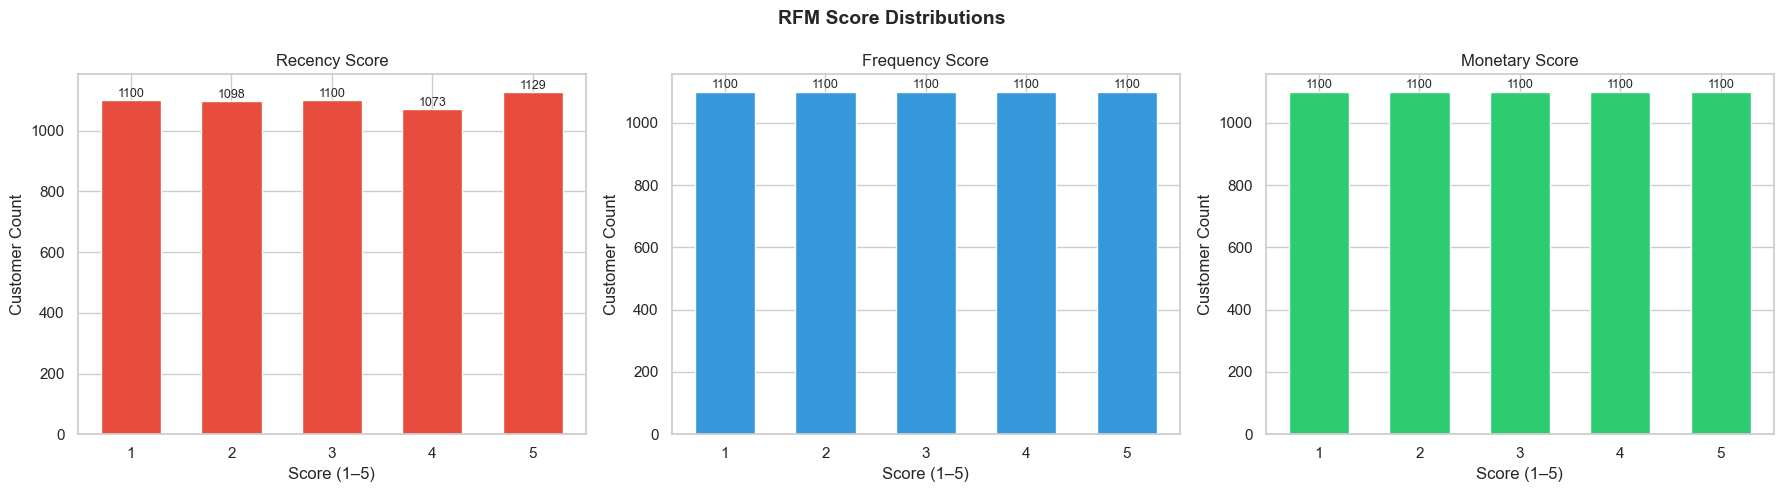

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Score Distributions', fontsize=14, fontweight='bold')

for ax, (col, color, title) in zip(axes, [
    ('R_score', '#e74c3c', 'Recency Score'),
    ('F_score', '#3498db', 'Frequency Score'),
    ('M_score', '#2ecc71', 'Monetary Score'),
]):
    counts = rfm[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white', width=0.6)
    ax.set_title(title)
    ax.set_xlabel('Score (1–5)')
    ax.set_ylabel('Customer Count')
    for x, y in zip(counts.index, counts.values):
        ax.text(x, y+10, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/seg_rfm_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. RFM Segment Distribution

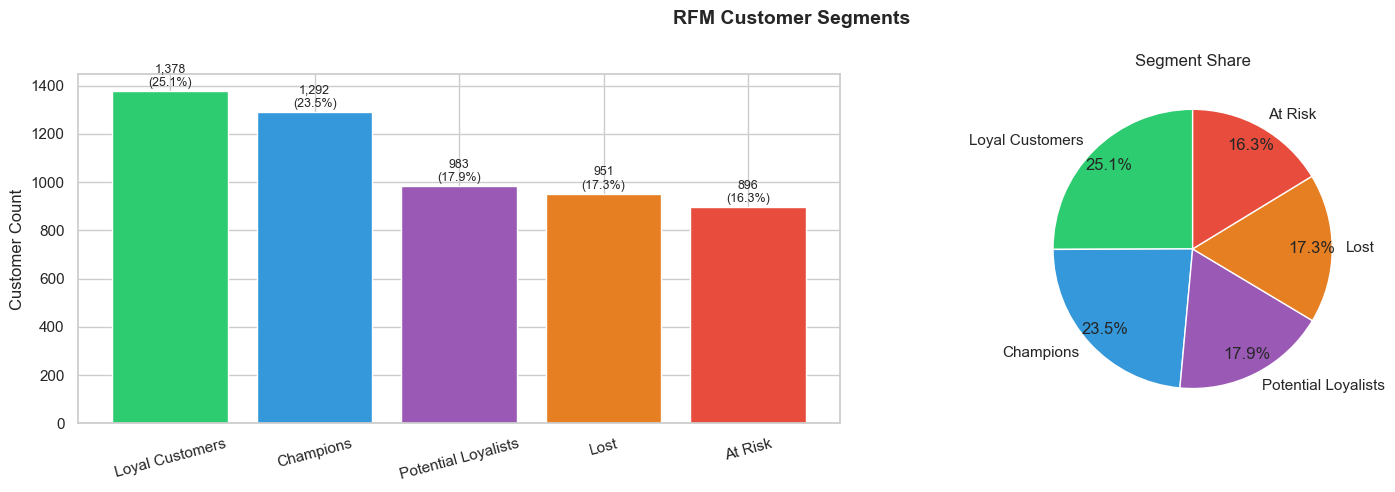

In [6]:
seg_counts = rfm['RFM_Segment'].value_counts()
colors_seg = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('RFM Customer Segments', fontsize=14, fontweight='bold')

# Bar chart
axes[0].bar(seg_counts.index, seg_counts.values,
            color=colors_seg[:len(seg_counts)], edgecolor='white')
for i, (idx, val) in enumerate(seg_counts.items()):
    axes[0].text(i, val+20, f'{val:,}\n({val/len(rfm)*100:.1f}%)', ha='center', fontsize=9)
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
axes[1].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=colors_seg[:len(seg_counts)],
            startangle=90, pctdistance=0.85)
axes[1].set_title('Segment Share')

plt.tight_layout()
plt.savefig('../output/seg_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Segment Profiles

In [7]:
profile = rfm.groupby('RFM_Segment')[['recency','frequency','monetary_value','RFM_Score']].mean().round(1)
profile.columns = ['Avg Recency (days)', 'Avg Frequency', 'Avg Monetary Value (₹)', 'Avg RFM Score']
profile_sorted = profile.sort_values('Avg RFM Score', ascending=False)
print(profile_sorted.to_string())
profile_sorted

                     Avg Recency (days)  Avg Frequency  Avg Monetary Value (₹)  Avg RFM Score
RFM_Segment                                                                                  
Champions                          44.9           12.8                 99509.4           13.9
Loyal Customers                    90.7            5.9                 32170.6           11.1
Potential Loyalists               219.2            2.9                 13837.8            8.1
At Risk                           405.2            1.2                  6745.4            5.5
Lost                              548.2            1.0                  2330.8            3.6


,Avg Recency (days),Avg Frequency,Avg Monetary Value (₹),Avg RFM Score
RFM_Segment,,,,
Champions,44.9,12.8,99509.4,13.9
Loyal Customers,90.7,5.9,32170.6,11.1
Potential Loyalists,219.2,2.9,13837.8,8.1
At Risk,405.2,1.2,6745.4,5.5
Lost,548.2,1.0,2330.8,3.6


## 8. K-Means — Elbow & Silhouette

  K=2  Inertia=10775  Silhouette=0.4607
  K=3  Inertia=6720  Silhouette=0.5340
  K=4  Inertia=5082  Silhouette=0.5435
  K=5  Inertia=3901  Silhouette=0.5483
  K=6  Inertia=2854  Silhouette=0.4951
  K=7  Inertia=2332  Silhouette=0.5004
  K=8  Inertia=1964  Silhouette=0.4837
  K=9  Inertia=1709  Silhouette=0.4444
  K=10  Inertia=1475  Silhouette=0.4545


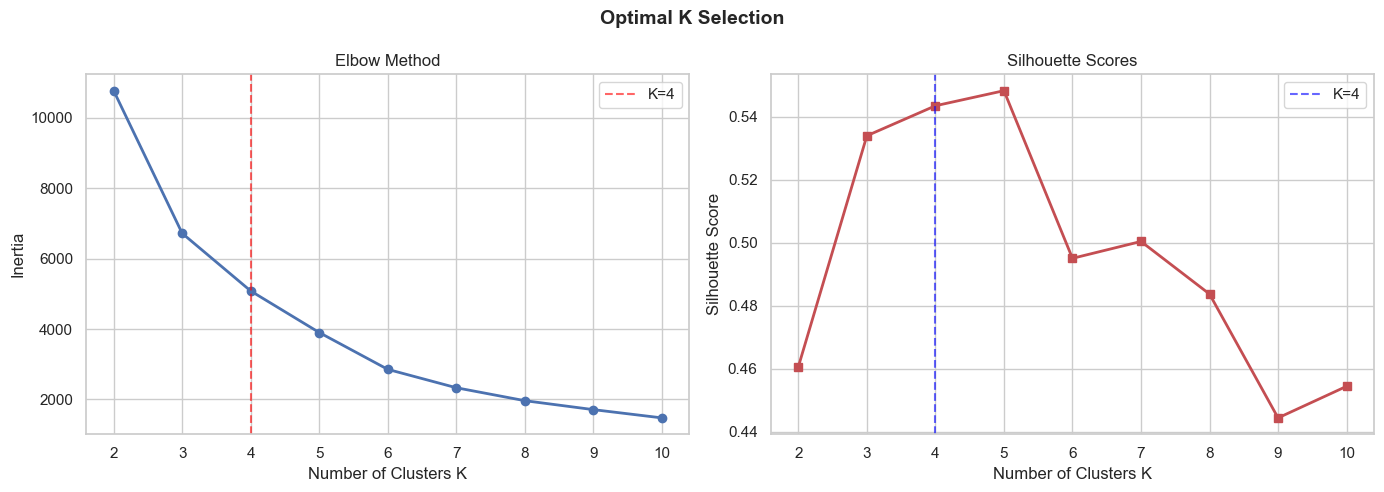

In [8]:
cluster_features = ['recency', 'frequency', 'monetary_value']
X_cluster = rfm[cluster_features].copy()

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f"  K={k}  Inertia={km.inertia_:.0f}  Silhouette={silhouette_score(X_scaled, km.labels_):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.6, label='K=4')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')
axes[1].axvline(4, color='blue', linestyle='--', alpha=0.6, label='K=4')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/seg_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Train K-Means (K=4)

In [9]:
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())

cluster_profile = rfm.groupby('Cluster')[cluster_features].mean().round(1)
cluster_profile.columns = ['Avg Recency', 'Avg Frequency', 'Avg Monetary (₹)']
print("\nCluster Profiles:")
print(cluster_profile)

Cluster Distribution:
Cluster
0    1733
1      80
2     156
3    3531
Name: count, dtype: int64

Cluster Profiles:
         Avg Recency  Avg Frequency  Avg Monetary (₹)
Cluster                                              
0              520.2            1.1            7279.4
1               34.5           19.3          555238.1
2               15.5           33.5           99528.7
3              106.5            5.9           34607.6


## 10. Cluster Visualisations

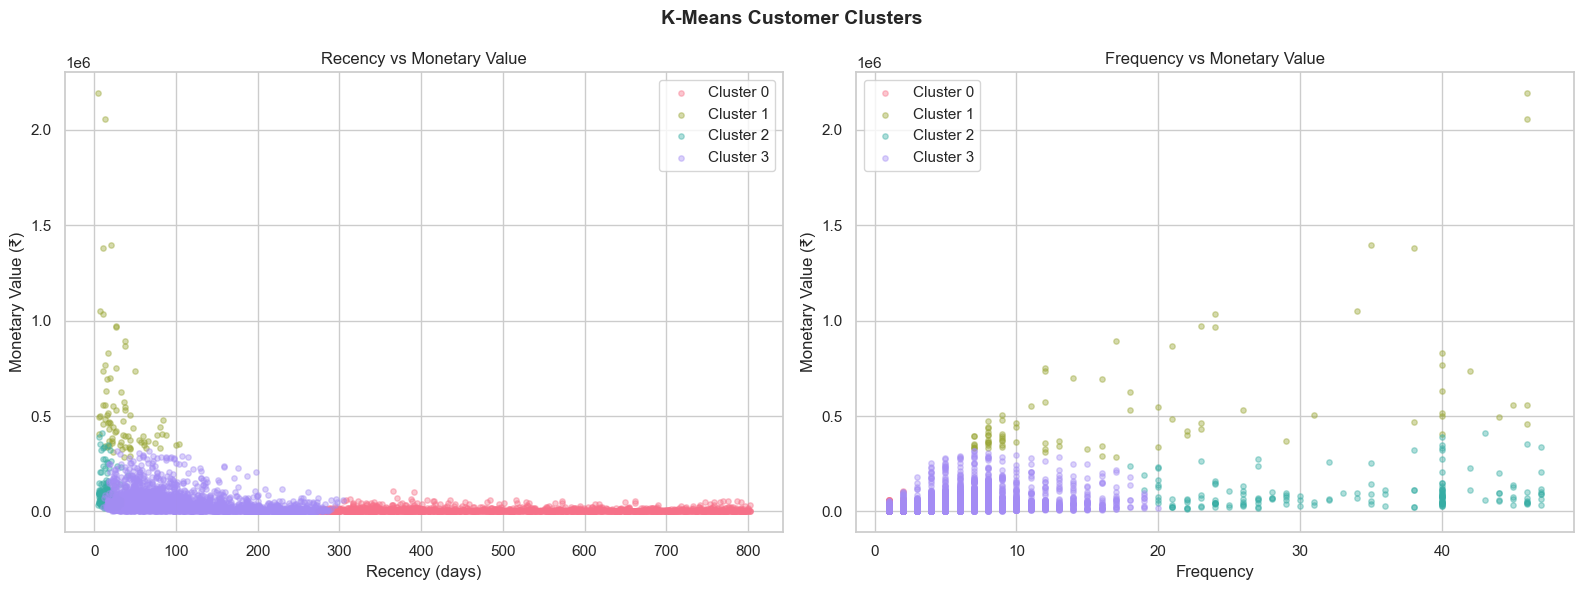

In [10]:
palette = sns.color_palette('husl', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Customer Clusters', fontsize=14, fontweight='bold')

for cluster in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster
    axes[0].scatter(rfm.loc[mask,'recency'], rfm.loc[mask,'monetary_value'],
                    alpha=0.4, s=15, label=f'Cluster {cluster}', color=palette[cluster])
    axes[1].scatter(rfm.loc[mask,'frequency'], rfm.loc[mask,'monetary_value'],
                    alpha=0.4, s=15, label=f'Cluster {cluster}', color=palette[cluster])

for ax, xlabel, title in [
    (axes[0], 'Recency (days)', 'Recency vs Monetary Value'),
    (axes[1], 'Frequency',      'Frequency vs Monetary Value'),
]:
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Monetary Value (₹)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('../output/seg_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cluster Radar Chart

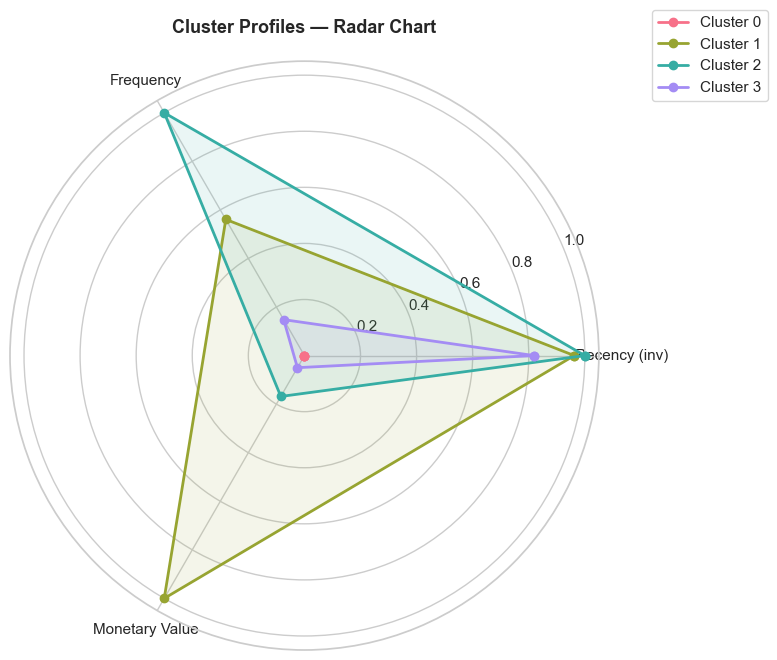

In [11]:
from matplotlib.patches import FancyArrowPatch

radar_features = ['recency','frequency','monetary_value']
cluster_means = rfm.groupby('Cluster')[radar_features].mean()

# Normalise 0-1
norm_means = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)
# Invert recency so higher = better
norm_means['recency'] = 1 - norm_means['recency']

angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette('husl', OPTIMAL_K)

for cluster in norm_means.index:
    values = norm_means.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}',
            color=colors_radar[cluster])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[cluster])

labels = ['Recency (inv)', 'Frequency', 'Monetary Value']
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=11)
ax.set_title('Cluster Profiles — Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../output/seg_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Models

In [12]:
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('../models/scaler_cluster.pkl', 'wb') as f:
    pickle.dump(scaler_cluster, f)

rfm.to_csv('../output/rfm_segments.csv', index=False)

print("Saved:")
print("   models/kmeans_model.pkl")
print("   models/scaler_cluster.pkl")
print("   output/rfm_segments.csv")
print(f"\nFinal RFM table shape: {rfm.shape}")
rfm.head()

Saved:
   models/kmeans_model.pkl
   models/scaler_cluster.pkl
   output/rfm_segments.csv

Final RFM table shape: (5500, 10)


,customer_id,recency,frequency,monetary_value,R_score,F_score,M_score,RFM_Score,RFM_Segment,Cluster
0,C00001,73,8,38583,4,4,4,12,Loyal Customers,3
1,C00002,280,2,3141,2,2,2,6,At Risk,3
2,C00003,24,8,162653,5,4,5,14,Champions,3
3,C00004,529,1,1008,1,1,1,3,Lost,0
4,C00005,49,9,27656,5,5,4,14,Champions,3
